In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import OrderedDict

In [2]:
mybl_lang = pd.read_csv('mybl_lang.csv')
mybl_lang = mybl_lang.loc[mybl_lang['name'] != 'Swift']
mybl_lang.drop('id', axis=1, inplace=True)

In [3]:
langs = mybl_lang.pivot(index='date_added', columns='name', values=['val', 'val_noexp', 'res_vac'])
langs.dropna(inplace=True)

In [4]:
Mind = pd.MultiIndex.from_tuples([('res', i) for i in langs['val'].columns])
langs_res = langs['res_vac'] * langs['val']
langs_res.columns = Mind
langs = pd.merge(langs, langs_res, how='left', on='date_added')

In [5]:
#normalization
for i in langs.columns:
    langs[i] = langs[i]/(max(langs[i]))

langs.describe()

val                                                        \
                1c         ABAP      Android Data scientist       DevOps   
count  1193.000000  1193.000000  1193.000000    1193.000000  1193.000000   
mean      0.758983     0.406165     0.539634       0.688322     0.641088   
std       0.106354     0.265733     0.226679       0.151078     0.123227   
min       0.556527     0.105000     0.271299       0.413926     0.398362   
25%       0.664207     0.190000     0.350453       0.558994     0.543187   
50%       0.736280     0.285000     0.419335       0.694391     0.599404   
75%       0.848474     0.685000     0.810876       0.820116     0.731943   
max       1.000000     1.000000     1.000000       1.000000     1.000000   

                                                                        ...  \
          Frontend       Golang         Java   Javascript       Python  ...   
count  1193.000000  1193.000000  1193.000000  1193.000000  1193.000000  ...   
mean      0.554979     0.731192     0.567560     0.556422     0.640796  ...   
std       0.220658     0.138763     0.195647     0.216616     0.143045  ...   
min       0.282471     0.473684     0.291237     0.300840     0.407917  ...   
25%       0.383103     0.616299     0.416429     0.382929     0.542169  ...   
50%       0.421718     0.699491     0.482319     0.426306     0.577883  ...   
75%       0.798502     0.876061     0.770042     0.810634     0.752582  ...   
max       1.000000     1.000000     1.000000     1.000000     1.000000  ...   

               res                                                      \
            Golang         Java   Javascript       Python         Ruby   
count  1193.000000  1193.000000  1193.000000  1193.000000  1193.000000   
mean      0.479573     0.717100     0.770427     0.632013     0.816813   
std       0.257792     0.151771     0.129354     0.222190     0.098729   
min       0.143678     0.482662     0.542913     0.291290     0.674804   
25%       0.213624     0.556200     0.639381     0.403458     0.712475   
50%       0.460523     0.739683     0.799133     0.648269     0.813315   
75%       0.720877     0.834586     0.869248     0.829946     0.896986   
max       1.000000     1.000000     1.000000     1.000000     1.000000   

                                                                        
             Scala          cpp           cs          iOS          php  
count  1193.000000  1193.000000  1193.000000  1193.000000  1193.000000  
mean      0.764707     0.718414     0.784306     0.717942     0.790605  
std       0.123722     0.137762     0.134515     0.175084     0.096659  
min       0.535117     0.516392     0.566000     0.445740     0.652963  
25%       0.651338     0.585342     0.639463     0.530883     0.692607  
50%       0.790134     0.720934     0.816098     0.749684     0.791894  
75%       0.835284     0.817752     0.894241     0.865273     0.844490  
max       1.000000     1.000000     1.000000     1.000000     1.000000  

[8 rows x 64 columns]

([<matplotlib.axis.XTick at 0x1efa11b5ad0>,
 [Text(281.0, 0, '2022-01-01'), Text(646.0, 0, '2023-01-01')])

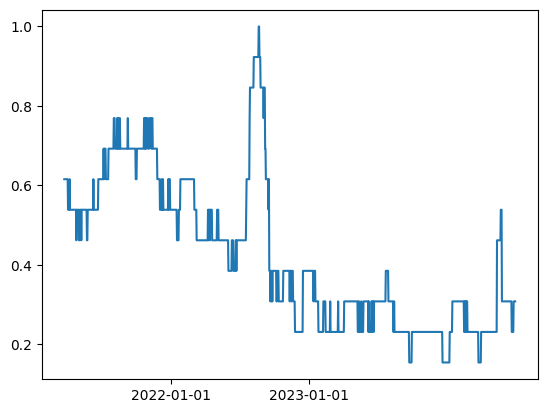

In [6]:
plt.plot(langs["val_noexp", "cpp"])
plt.xticks(['2022-01-01', '2023-01-01'])

In [7]:
def graphs(column, window):
    colmns = langs[column].columns

    langs1 = langs[column].copy()
    langs2 = langs[column].copy()

    fig, ax = plt.subplots()
    fig.set_size_inches(15, 8)
    labels = []
    col = ""

    for i in colmns:
        langs1[i] = langs1[i].rolling(window=window).mean()
        langs2[i] = langs2[i].rolling(window=window).mean()
        langs2[i] = langs2[i].shift(window)

        if col[:2] != 'Py':
            ax.plot(langs1[i] - langs2[i])
            labels.append(langs2[i].name)
            col = i
        else:
            ax.plot(langs1[i] - langs2[i], linestyle='--')
            labels.append(langs2[i].name)
            col = 'Py'

    ax.legend(labels)
    ax.axhline(y=0, color='k')
    plt.xticks('')
    #ax.set_xticklabels((date), rotation=90)

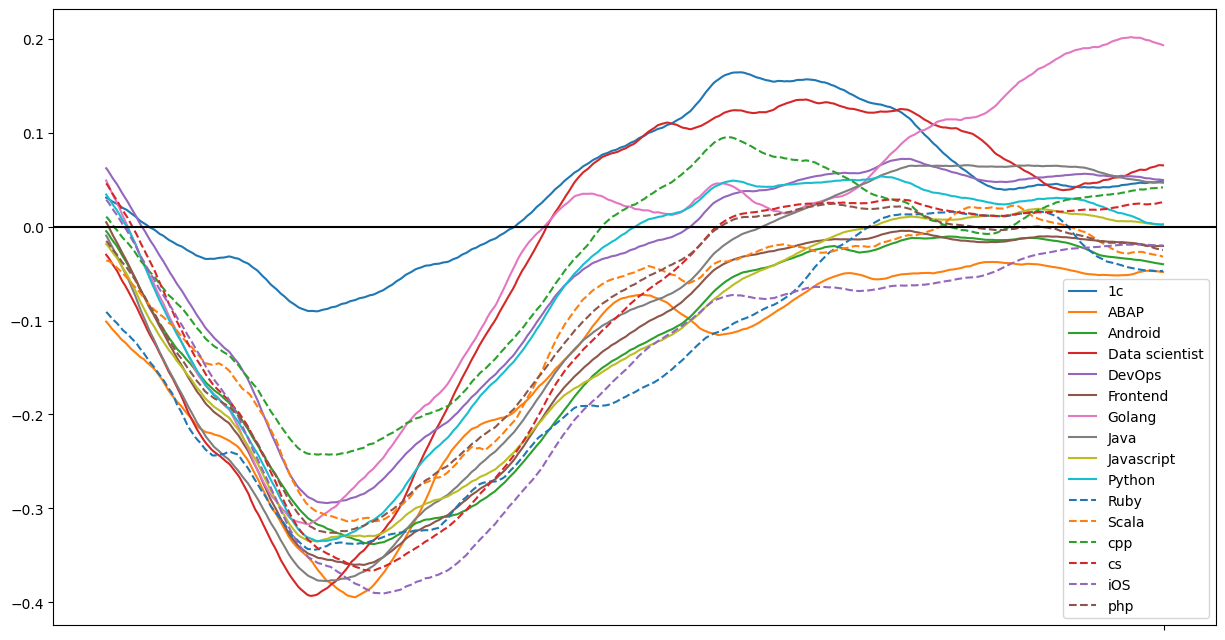

In [8]:
graphs('val', 200)

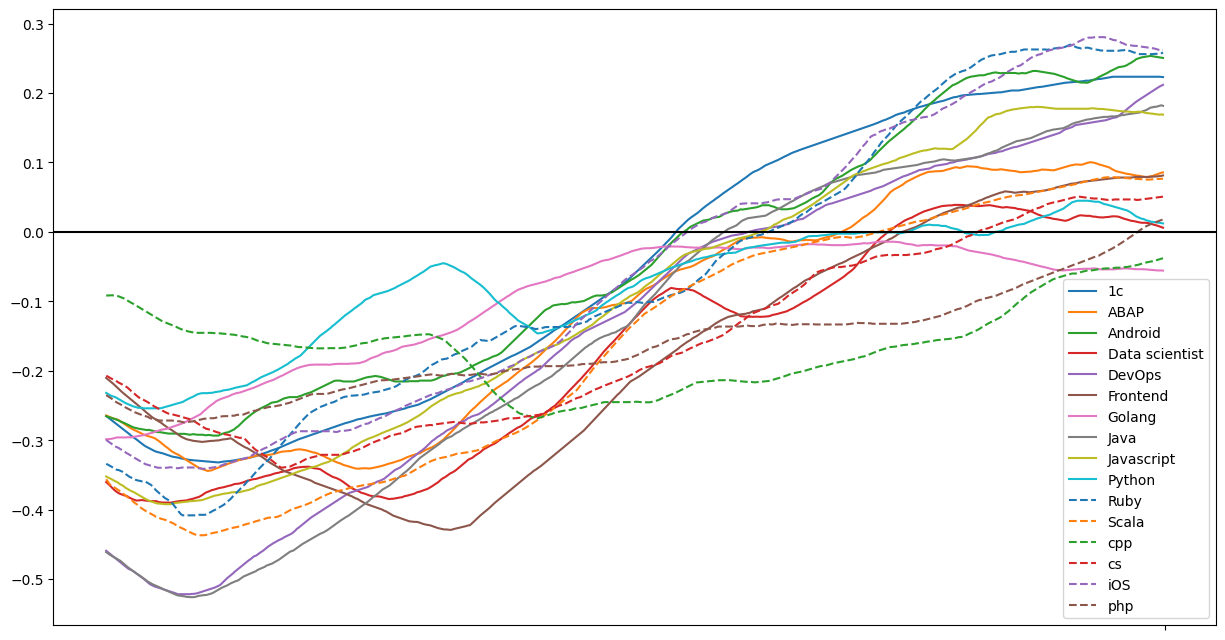

In [9]:
graphs('val_noexp', 300)

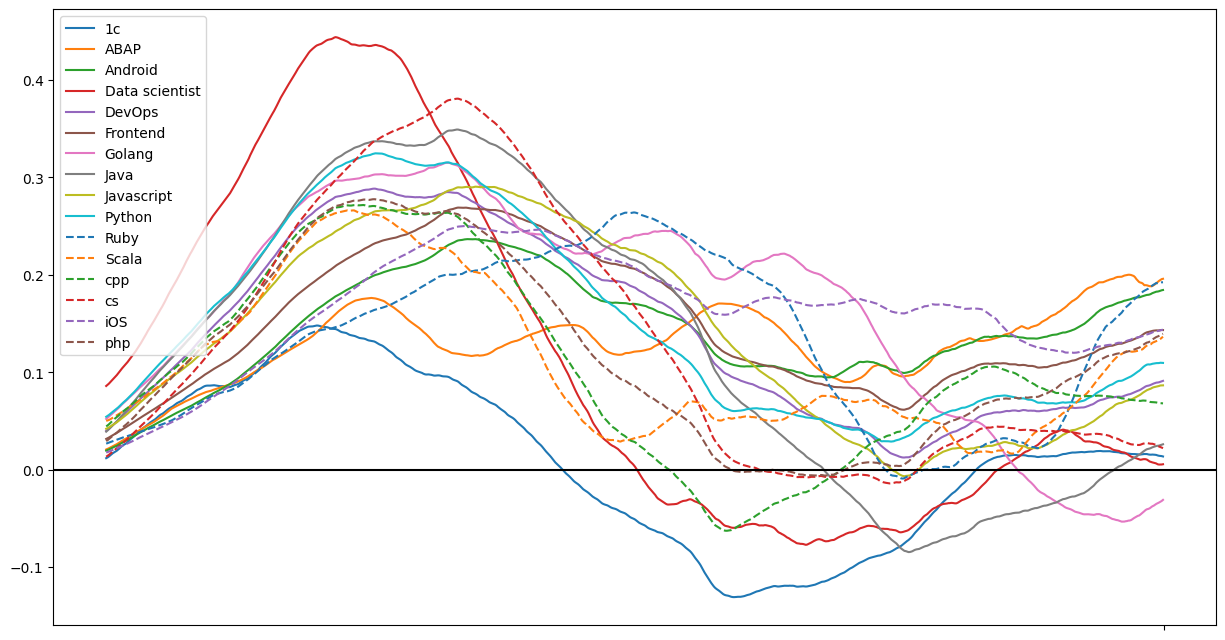

In [10]:
graphs('res_vac', 200)

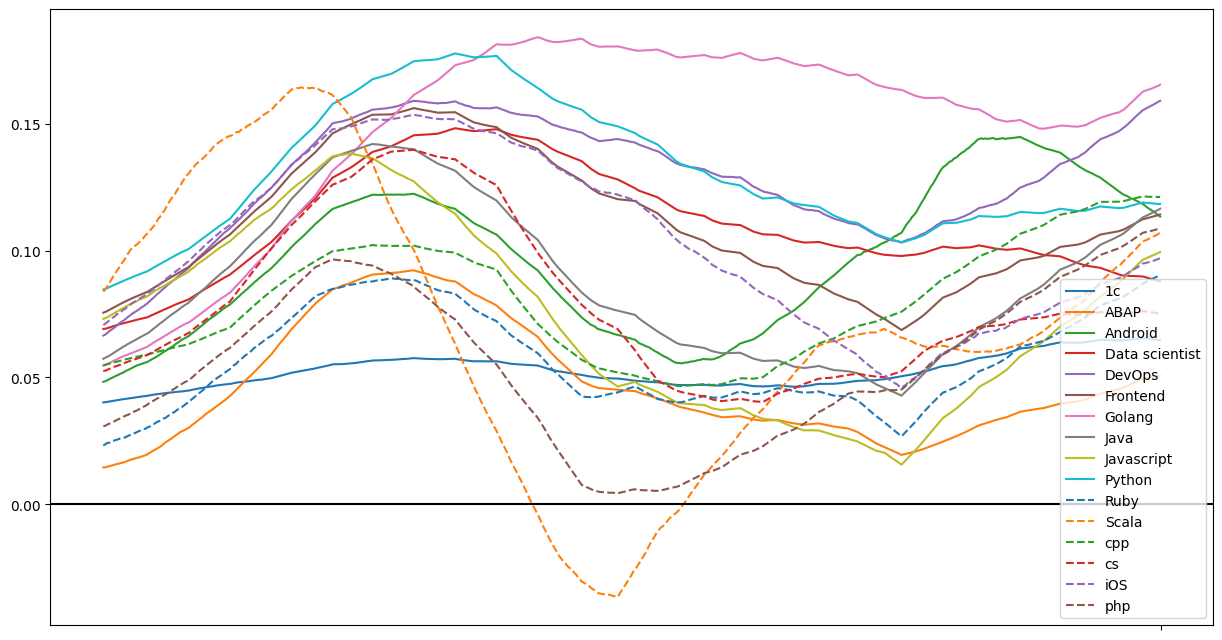

In [11]:
graphs('res', 200)

In [12]:
langs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1193 entries, 2021-03-26 to 2024-07-02
Data columns (total 64 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   (val, 1c)                    1193 non-null   float64
 1   (val, ABAP)                  1193 non-null   float64
 2   (val, Android)               1193 non-null   float64
 3   (val, Data scientist)        1193 non-null   float64
 4   (val, DevOps)                1193 non-null   float64
 5   (val, Frontend)              1193 non-null   float64
 6   (val, Golang)                1193 non-null   float64
 7   (val, Java)                  1193 non-null   float64
 8   (val, Javascript)            1193 non-null   float64
 9   (val, Python)                1193 non-null   float64
 10  (val, Ruby)                  1193 non-null   float64
 11  (val, Scala)                 1193 non-null   float64
 12  (val, cpp)                   1193 non-null   float64
 13  (val, cs

In [13]:
import seaborn as sns

def corr(colmns):
    plt.figure(figsize=(10,10))
    sns.set(font_scale=1.0)
    sns.heatmap(pd.DataFrame(langs[colmns]).corr(),cmap='GnBu',annot=True)

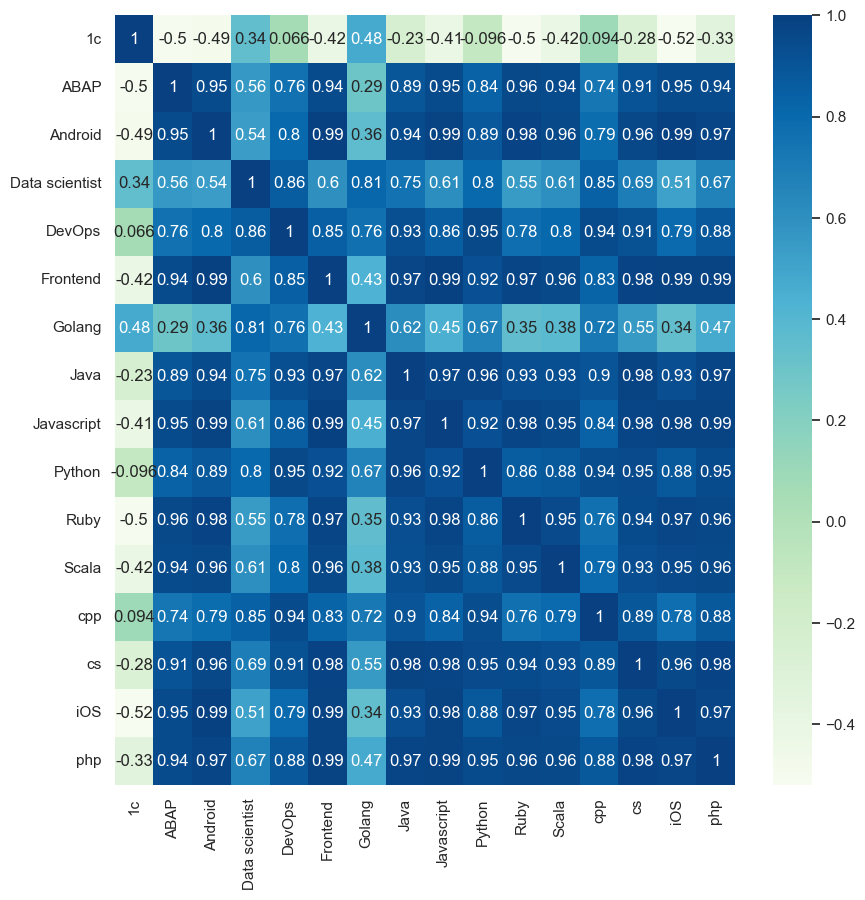

In [14]:
corr('val')

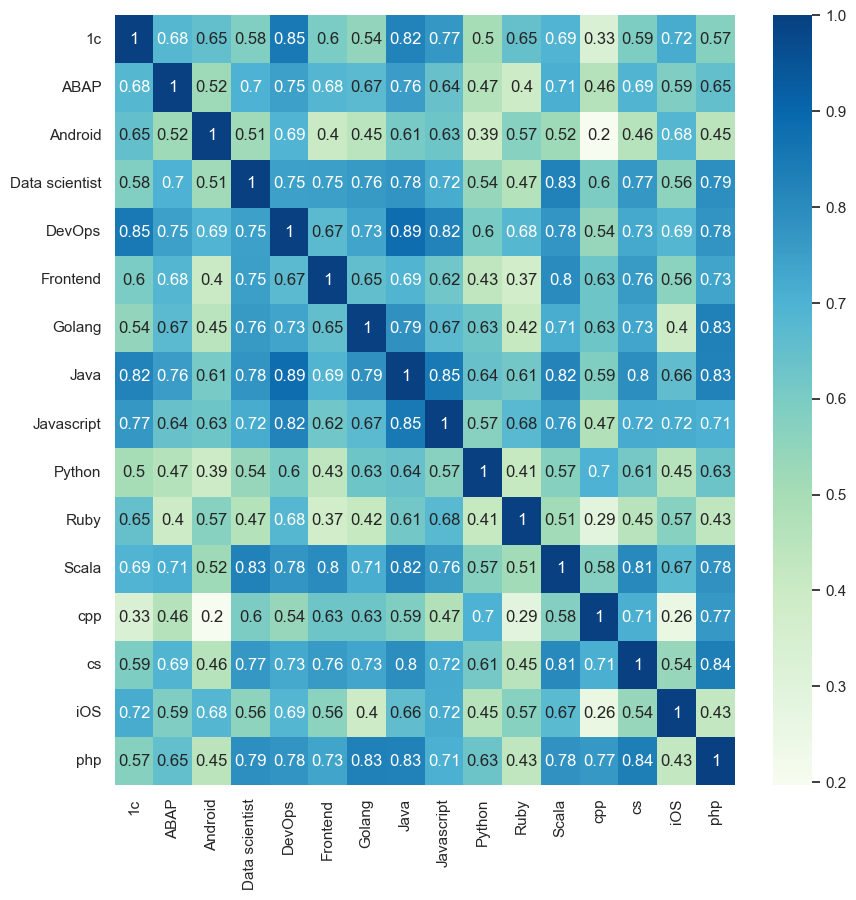

In [15]:
corr('val_noexp')

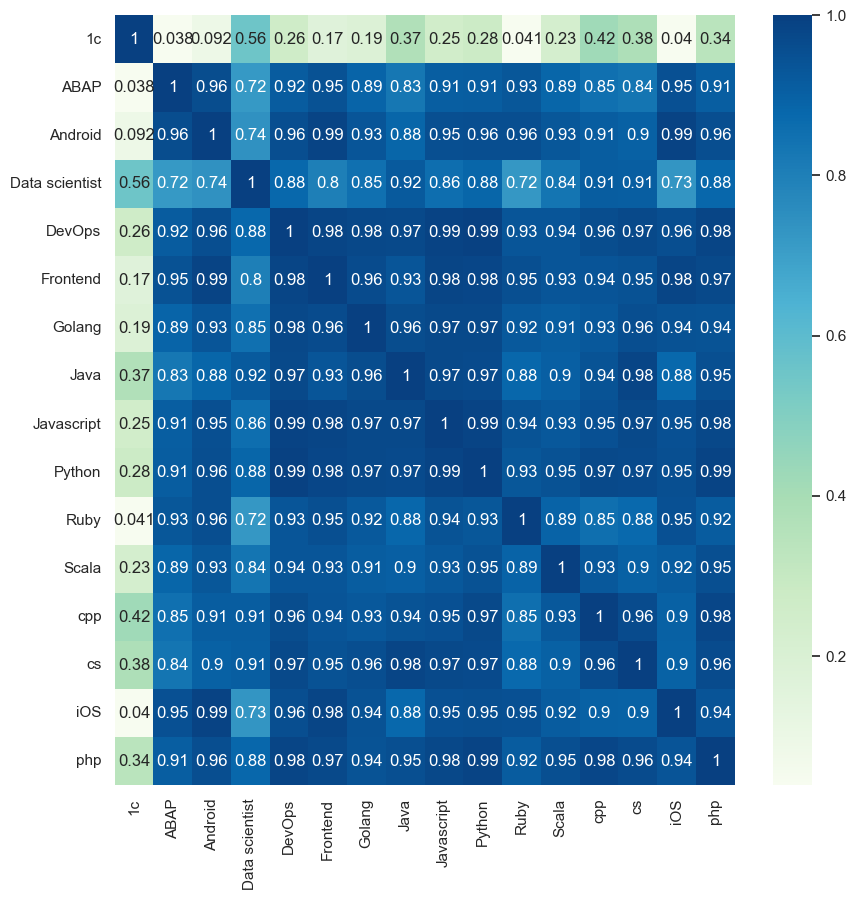

In [16]:
corr('res_vac')

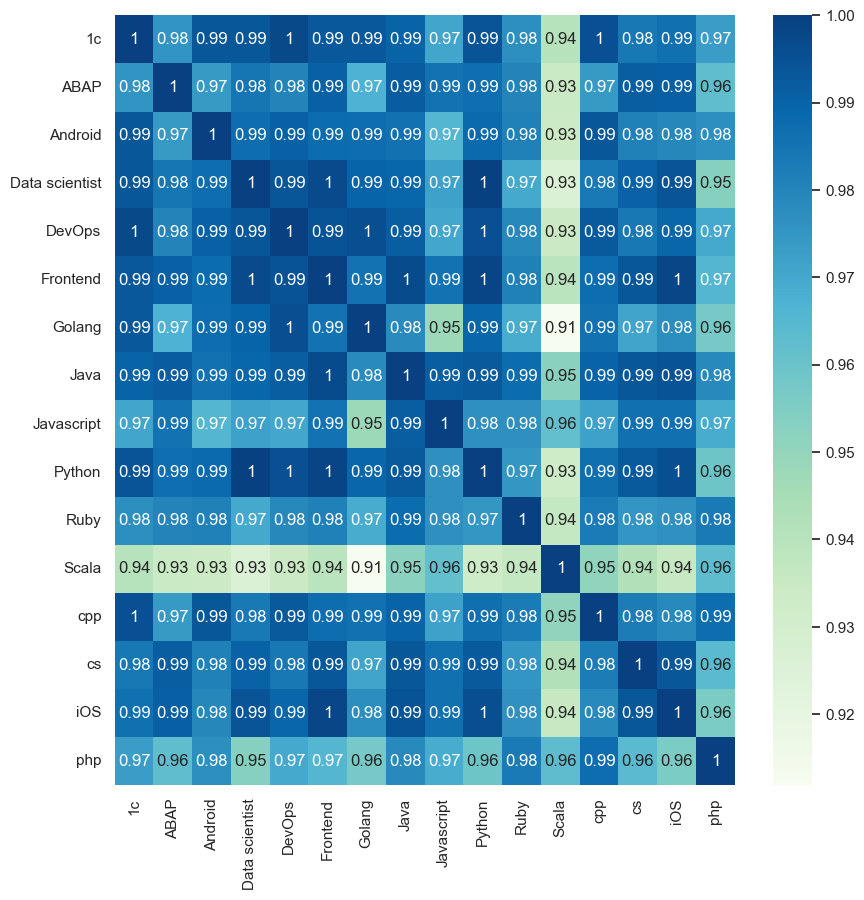

In [17]:
corr('res')

In [21]:
langs.index = pd.to_datetime(langs.index)

def year(x):
    fig, ax = plt.subplots()
    fig.set_size_inches(15, 8)
    plt.plot(langs[x].groupby(langs.index.strftime('%m-%d')).median().median(axis=1))
    plt.xticks([str(i).zfill(2) + "-01" for i in range(1, 13)])
    plt.grid()

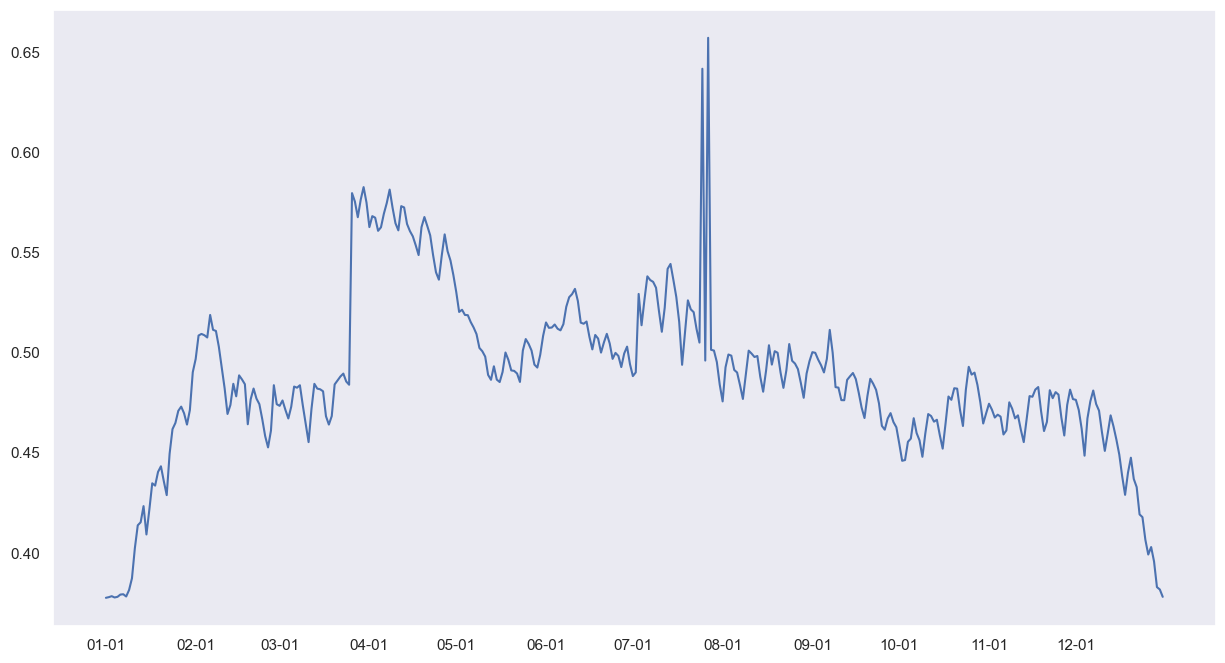

In [22]:
year("val")

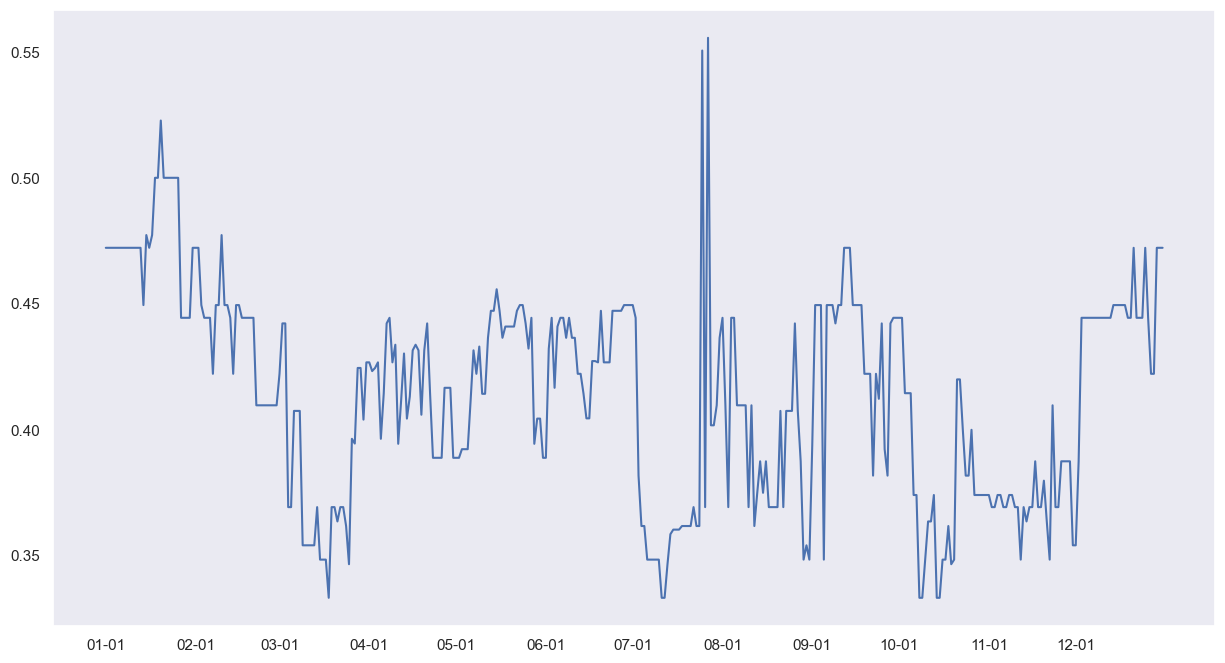

In [23]:
year("val_noexp")

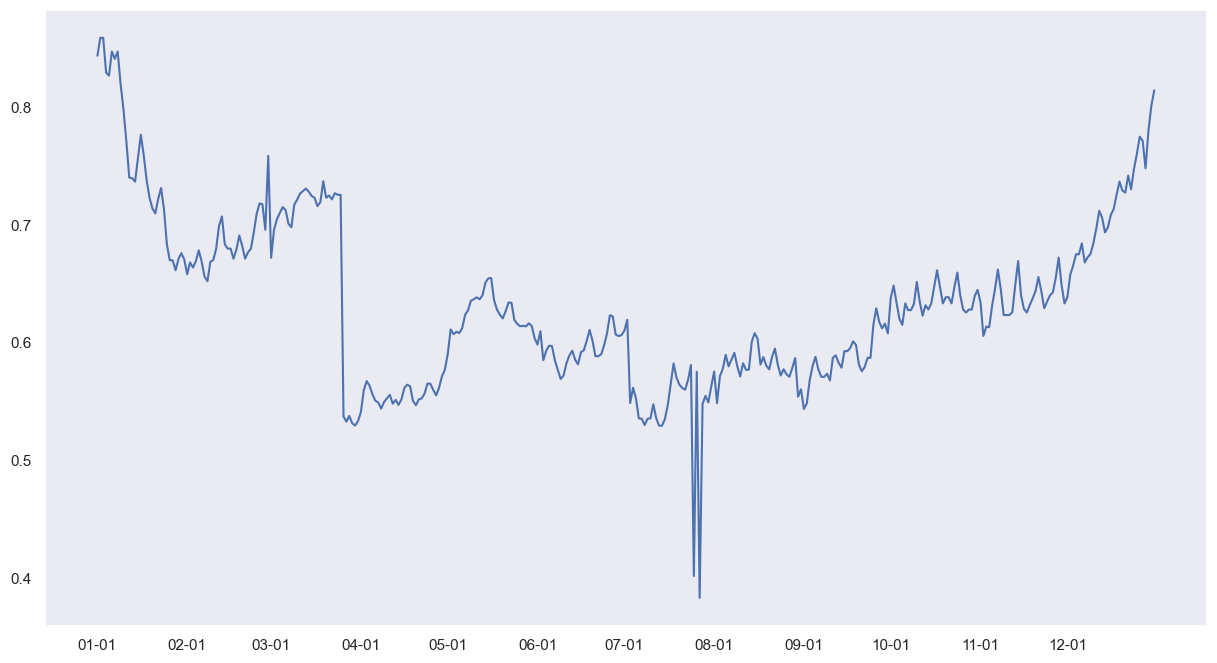

In [24]:
year("res_vac")

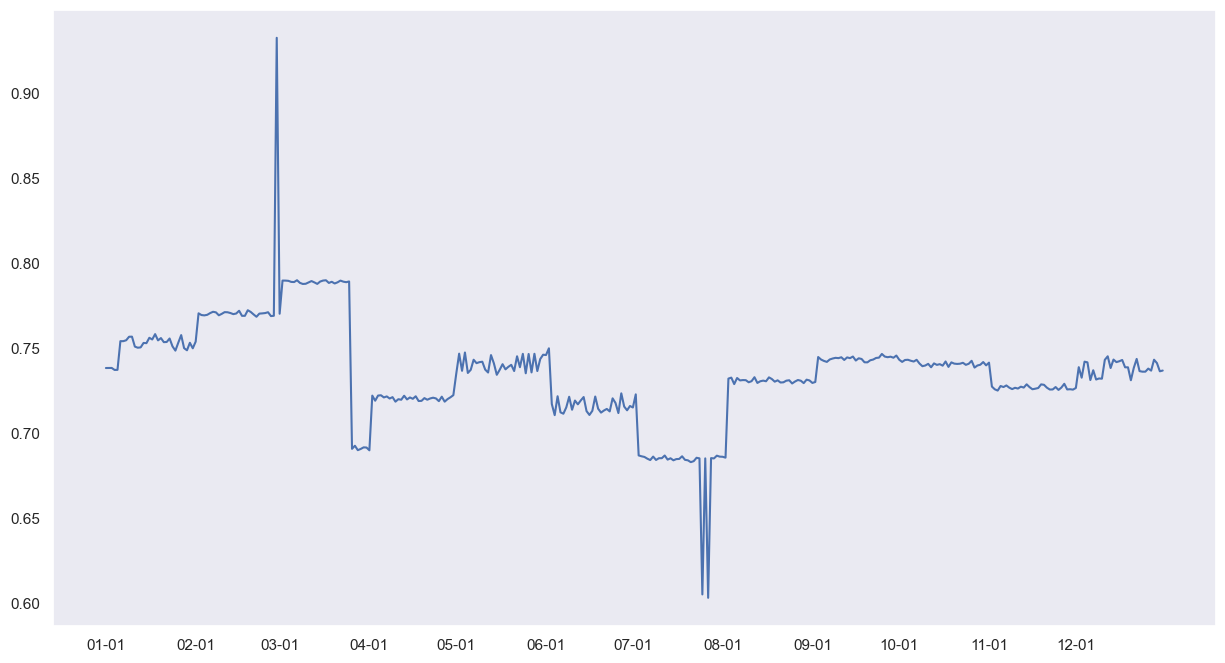

In [25]:
year("res")

In [32]:
def graphs(column):
    colmns = langs[column].columns
    langs1 = langs[column].copy()

    fig, ax = plt.subplots()
    fig.set_size_inches(15, 8)
    labels = []
    col = ""

    for i in colmns:
        if col[:2] != 'Py':
            ax.plot(langs1[i])
            labels.append(langs1[i].name)
            col = i
        else:
            ax.plot(langs1[i], linestyle='--')
            labels.append(langs1[i].name)
            col = 'Py'

    ax.legend(labels)
    #plt.xticks('')

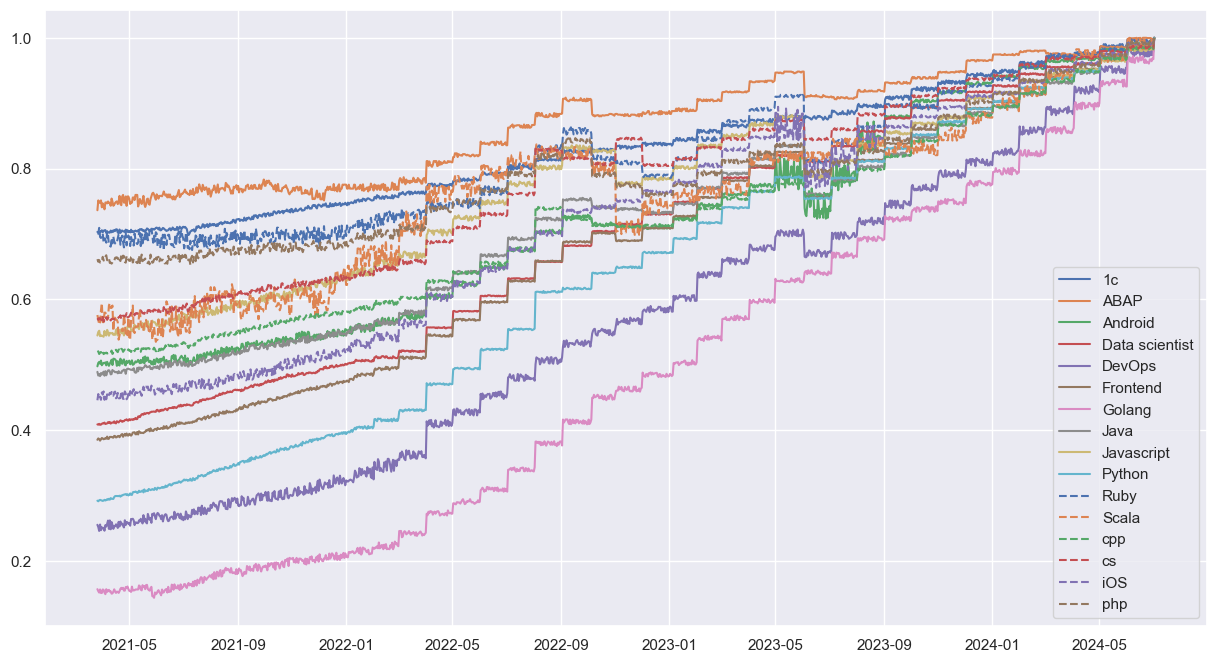

In [34]:
graphs("res")